In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from spmd_reflection.cli import run, run_tx_sweep
from spmd_reflection.postprocess.masks import (tci_il_mask, tci_rl_mask,
                                               mpi_il_mask, mpi_rl_mask,
                                               check_tci_il, check_tci_rl,
                                               check_mpi_il, check_mpi_rl,
                                               check_ms_il)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "font.size": 11})

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

In [2]:
results, tx_phy_voltage, rx_phy_voltages = run(CONFIG_PATH)

freqs_hz  = results.frequency_hz
freqs_mhz = freqs_hz / 1e6

n_rx: int = results.rx_to_tx_db.shape[1]
n_drops: int = results.il_tci_db.shape[1]

print(f"Frequenzbereich: {freqs_mhz[0]:.2f} – {freqs_mhz[-1]:.2f} MHz")
print(f"Anzahl Drops gesamt: {n_drops}")
print(f"Anzahl RX-Drops: {n_rx}")

Frequenzbereich: 0.30 – 40.00 MHz
Anzahl Drops gesamt: 16
Anzahl RX-Drops: 15


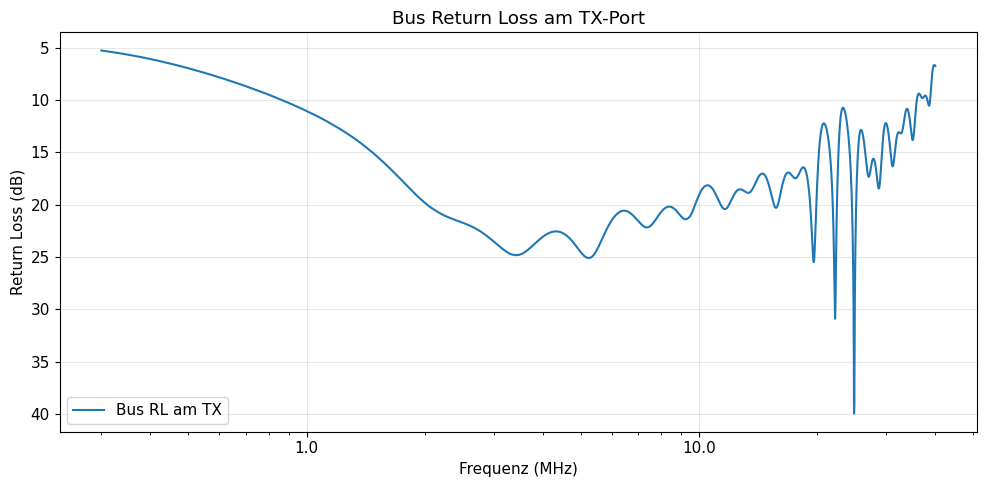

In [3]:
fig, ax = plt.subplots()

ax.plot(freqs_mhz, results.rl_db, label="Bus RL am TX")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Return Loss (dB)")
ax.set_xscale("log")
ax.set_title("Bus Return Loss am TX-Port")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=6))
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

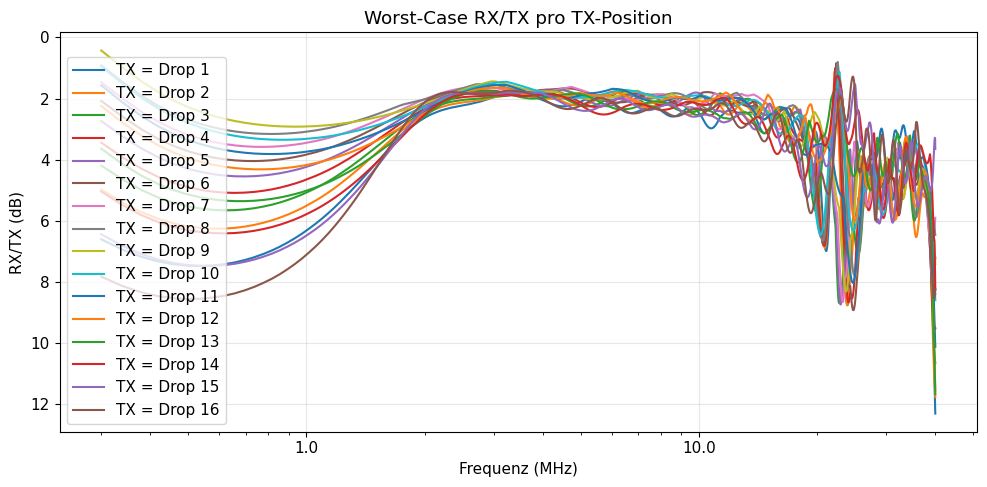

In [4]:
sweep = run_tx_sweep(CONFIG_PATH)

fig, ax = plt.subplots()
for tx_idx, bus in enumerate(sweep):
    if bus.rx_to_tx_db.shape[1] > 0:
        worst_case = bus.rx_to_tx_db.max(axis=1)
        ax.plot(freqs_mhz, worst_case, label=f"TX = Drop {tx_idx+1}")

ax.invert_yaxis()
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("RX/TX (dB)")
ax.set_xscale("log")
ax.set_title("Worst-Case RX/TX pro TX-Position")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=6))
ax.legend()
plt.tight_layout()
plt.show()

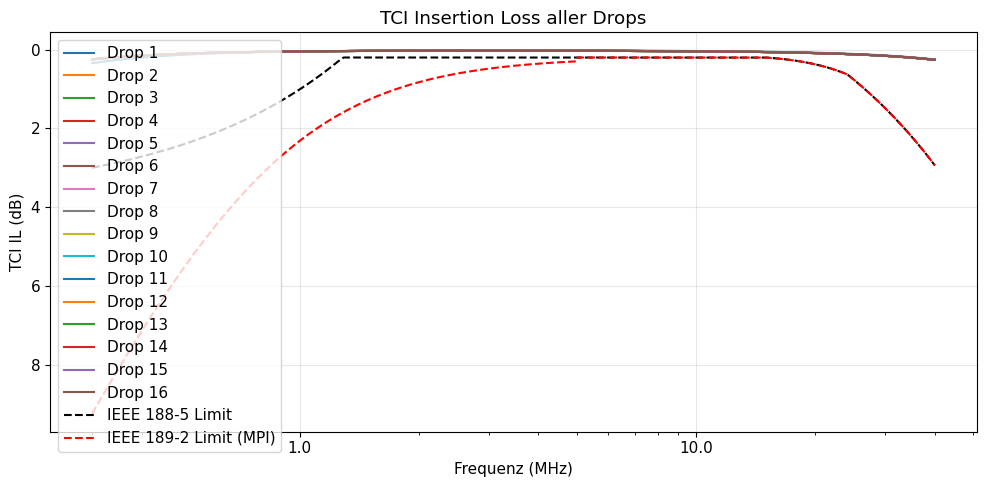

Drop 1: IL 188-5 ✓  IL 189-2 ✓
Drop 2: IL 188-5 ✓  IL 189-2 ✓
Drop 3: IL 188-5 ✓  IL 189-2 ✓
Drop 4: IL 188-5 ✓  IL 189-2 ✓
Drop 5: IL 188-5 ✓  IL 189-2 ✓
Drop 6: IL 188-5 ✓  IL 189-2 ✓
Drop 7: IL 188-5 ✓  IL 189-2 ✓
Drop 8: IL 188-5 ✓  IL 189-2 ✓
Drop 9: IL 188-5 ✓  IL 189-2 ✓
Drop 10: IL 188-5 ✓  IL 189-2 ✓
Drop 11: IL 188-5 ✓  IL 189-2 ✓
Drop 12: IL 188-5 ✓  IL 189-2 ✓
Drop 13: IL 188-5 ✓  IL 189-2 ✓
Drop 14: IL 188-5 ✓  IL 189-2 ✓
Drop 15: IL 188-5 ✓  IL 189-2 ✓
Drop 16: IL 188-5 ✓  IL 189-2 ✓


In [5]:
il_limit_188 = tci_il_mask(freqs_hz)
il_limit_189 = mpi_il_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.il_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, il_limit_188, "k--", label="IEEE 188-5 Limit")
ax.plot(freqs_mhz, il_limit_189, "r--", label="IEEE 189-2 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI IL (dB)")
ax.set_xscale("log")
ax.set_title("TCI Insertion Loss aller Drops")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=6))
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_il(freqs_hz, results.il_tci_db)
ok_189 = check_mpi_il(freqs_hz, results.il_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: IL 188-5 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"IL 189-2 {'✓' if ok_189[:, i].all() else '✗'}")

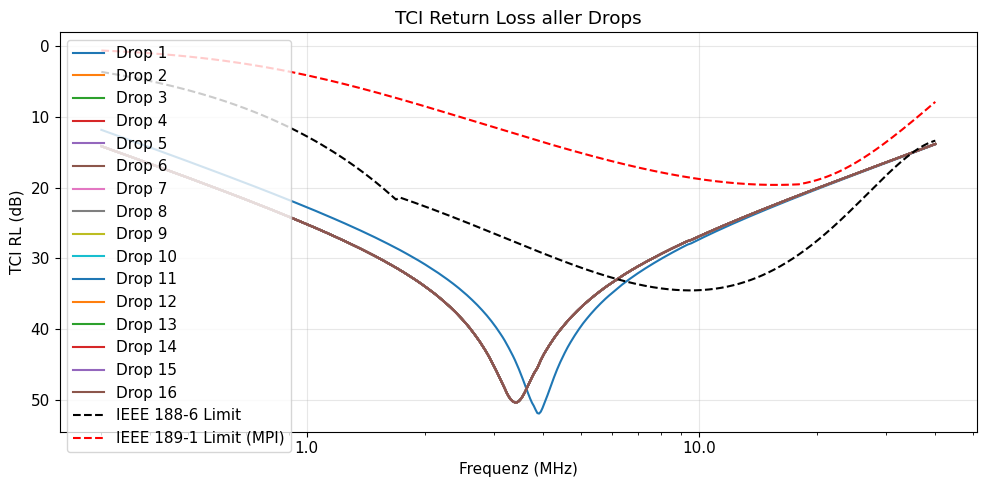

Drop 1: RL 188-6 ✗  RL 189-1 ✓
Drop 2: RL 188-6 ✗  RL 189-1 ✓
Drop 3: RL 188-6 ✗  RL 189-1 ✓
Drop 4: RL 188-6 ✗  RL 189-1 ✓
Drop 5: RL 188-6 ✗  RL 189-1 ✓
Drop 6: RL 188-6 ✗  RL 189-1 ✓
Drop 7: RL 188-6 ✗  RL 189-1 ✓
Drop 8: RL 188-6 ✗  RL 189-1 ✓
Drop 9: RL 188-6 ✗  RL 189-1 ✓
Drop 10: RL 188-6 ✗  RL 189-1 ✓
Drop 11: RL 188-6 ✗  RL 189-1 ✓
Drop 12: RL 188-6 ✗  RL 189-1 ✓
Drop 13: RL 188-6 ✗  RL 189-1 ✓
Drop 14: RL 188-6 ✗  RL 189-1 ✓
Drop 15: RL 188-6 ✗  RL 189-1 ✓
Drop 16: RL 188-6 ✗  RL 189-1 ✓


In [6]:
rl_limit_188 = tci_rl_mask(freqs_hz)
rl_limit_189 = mpi_rl_mask(freqs_hz)

fig, ax = plt.subplots()

for i in range(n_drops):
    ax.plot(freqs_mhz, results.rl_tci_db[:, i], label=f"Drop {i+1}")

ax.plot(freqs_mhz, rl_limit_188, "k--", label="IEEE 188-6 Limit")
ax.plot(freqs_mhz, rl_limit_189, "r--", label="IEEE 189-1 Limit (MPI)")

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("TCI RL (dB)")
ax.set_xscale("log")
ax.set_title("TCI Return Loss aller Drops")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=6))
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Konformitäts-Check
ok_188 = check_tci_rl(freqs_hz, results.rl_tci_db)
ok_189 = check_mpi_rl(freqs_hz, results.rl_tci_db)
for i in range(n_drops):
    print(f"Drop {i+1}: RL 188-6 {'✓' if ok_188[:, i].all() else '✗'}  "
          f"RL 189-1 {'✓' if ok_189[:, i].all() else '✗'}")

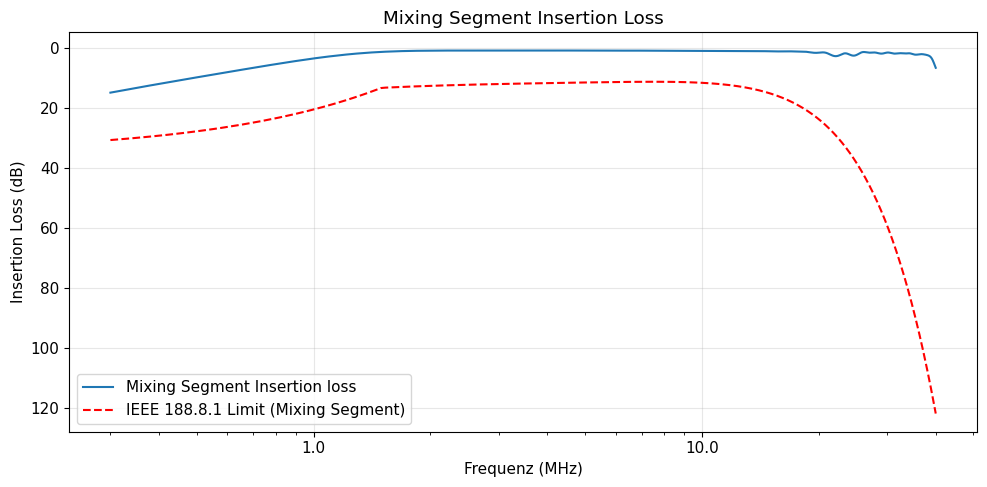

Mixing Segment 188-3: ✓  


In [7]:
from spmd_reflection.postprocess.masks import mixing_segment_il_mask


fig, ax = plt.subplots()

ms_il_limit = mixing_segment_il_mask(freqs_hz)

ax.plot(freqs_mhz, results.il_ms_db, label="Mixing Segment Insertion loss")
ax.plot(freqs_mhz, ms_il_limit, "r--", label="IEEE 188.8.1 Limit (Mixing Segment)")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Insertion Loss (dB)")
ax.set_title("Mixing Segment Insertion Loss")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=6))
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

ok_188_3 = check_ms_il(freqs_hz,results.il_ms_db)
print(f"Mixing Segment 188-3: {'✓' if ok_188_3[:].all() else '✗'}  ")


In [8]:
print("=" * 50)
print("KONFORMITÄTS-ZUSAMMENFASSUNG")
print("=" * 50)

checks = {
    "TCI IL (188-5)":  check_tci_il(freqs_hz, results.il_tci_db),
    "TCI RL (188-6)":  check_tci_rl(freqs_hz, results.rl_tci_db),
    "MPI IL (189-2)":  check_mpi_il(freqs_hz, results.il_tci_db),
    "MPI RL (189-1)":  check_mpi_rl(freqs_hz, results.rl_tci_db)}

for check_name, conformant in checks.items():
    for i in range(n_drops):
        status = "PASS ✓" if conformant[:, i].all() else "FAIL ✗"
        print(f"  Drop {i+1} – {check_name}: {status}")
    print()

ms_il_conformant = check_ms_il(freqs_hz, results.il_ms_db)
status = "PASS ✓" if ms_il_conformant[:].all() else "FAIL ✗"
print(f"  Mixing Segment IL (188-3): {status}")

KONFORMITÄTS-ZUSAMMENFASSUNG
  Drop 1 – TCI IL (188-5): PASS ✓
  Drop 2 – TCI IL (188-5): PASS ✓
  Drop 3 – TCI IL (188-5): PASS ✓
  Drop 4 – TCI IL (188-5): PASS ✓
  Drop 5 – TCI IL (188-5): PASS ✓
  Drop 6 – TCI IL (188-5): PASS ✓
  Drop 7 – TCI IL (188-5): PASS ✓
  Drop 8 – TCI IL (188-5): PASS ✓
  Drop 9 – TCI IL (188-5): PASS ✓
  Drop 10 – TCI IL (188-5): PASS ✓
  Drop 11 – TCI IL (188-5): PASS ✓
  Drop 12 – TCI IL (188-5): PASS ✓
  Drop 13 – TCI IL (188-5): PASS ✓
  Drop 14 – TCI IL (188-5): PASS ✓
  Drop 15 – TCI IL (188-5): PASS ✓
  Drop 16 – TCI IL (188-5): PASS ✓

  Drop 1 – TCI RL (188-6): FAIL ✗
  Drop 2 – TCI RL (188-6): FAIL ✗
  Drop 3 – TCI RL (188-6): FAIL ✗
  Drop 4 – TCI RL (188-6): FAIL ✗
  Drop 5 – TCI RL (188-6): FAIL ✗
  Drop 6 – TCI RL (188-6): FAIL ✗
  Drop 7 – TCI RL (188-6): FAIL ✗
  Drop 8 – TCI RL (188-6): FAIL ✗
  Drop 9 – TCI RL (188-6): FAIL ✗
  Drop 10 – TCI RL (188-6): FAIL ✗
  Drop 11 – TCI RL (188-6): FAIL ✗
  Drop 12 – TCI RL (188-6): FAIL ✗
  Drop 1

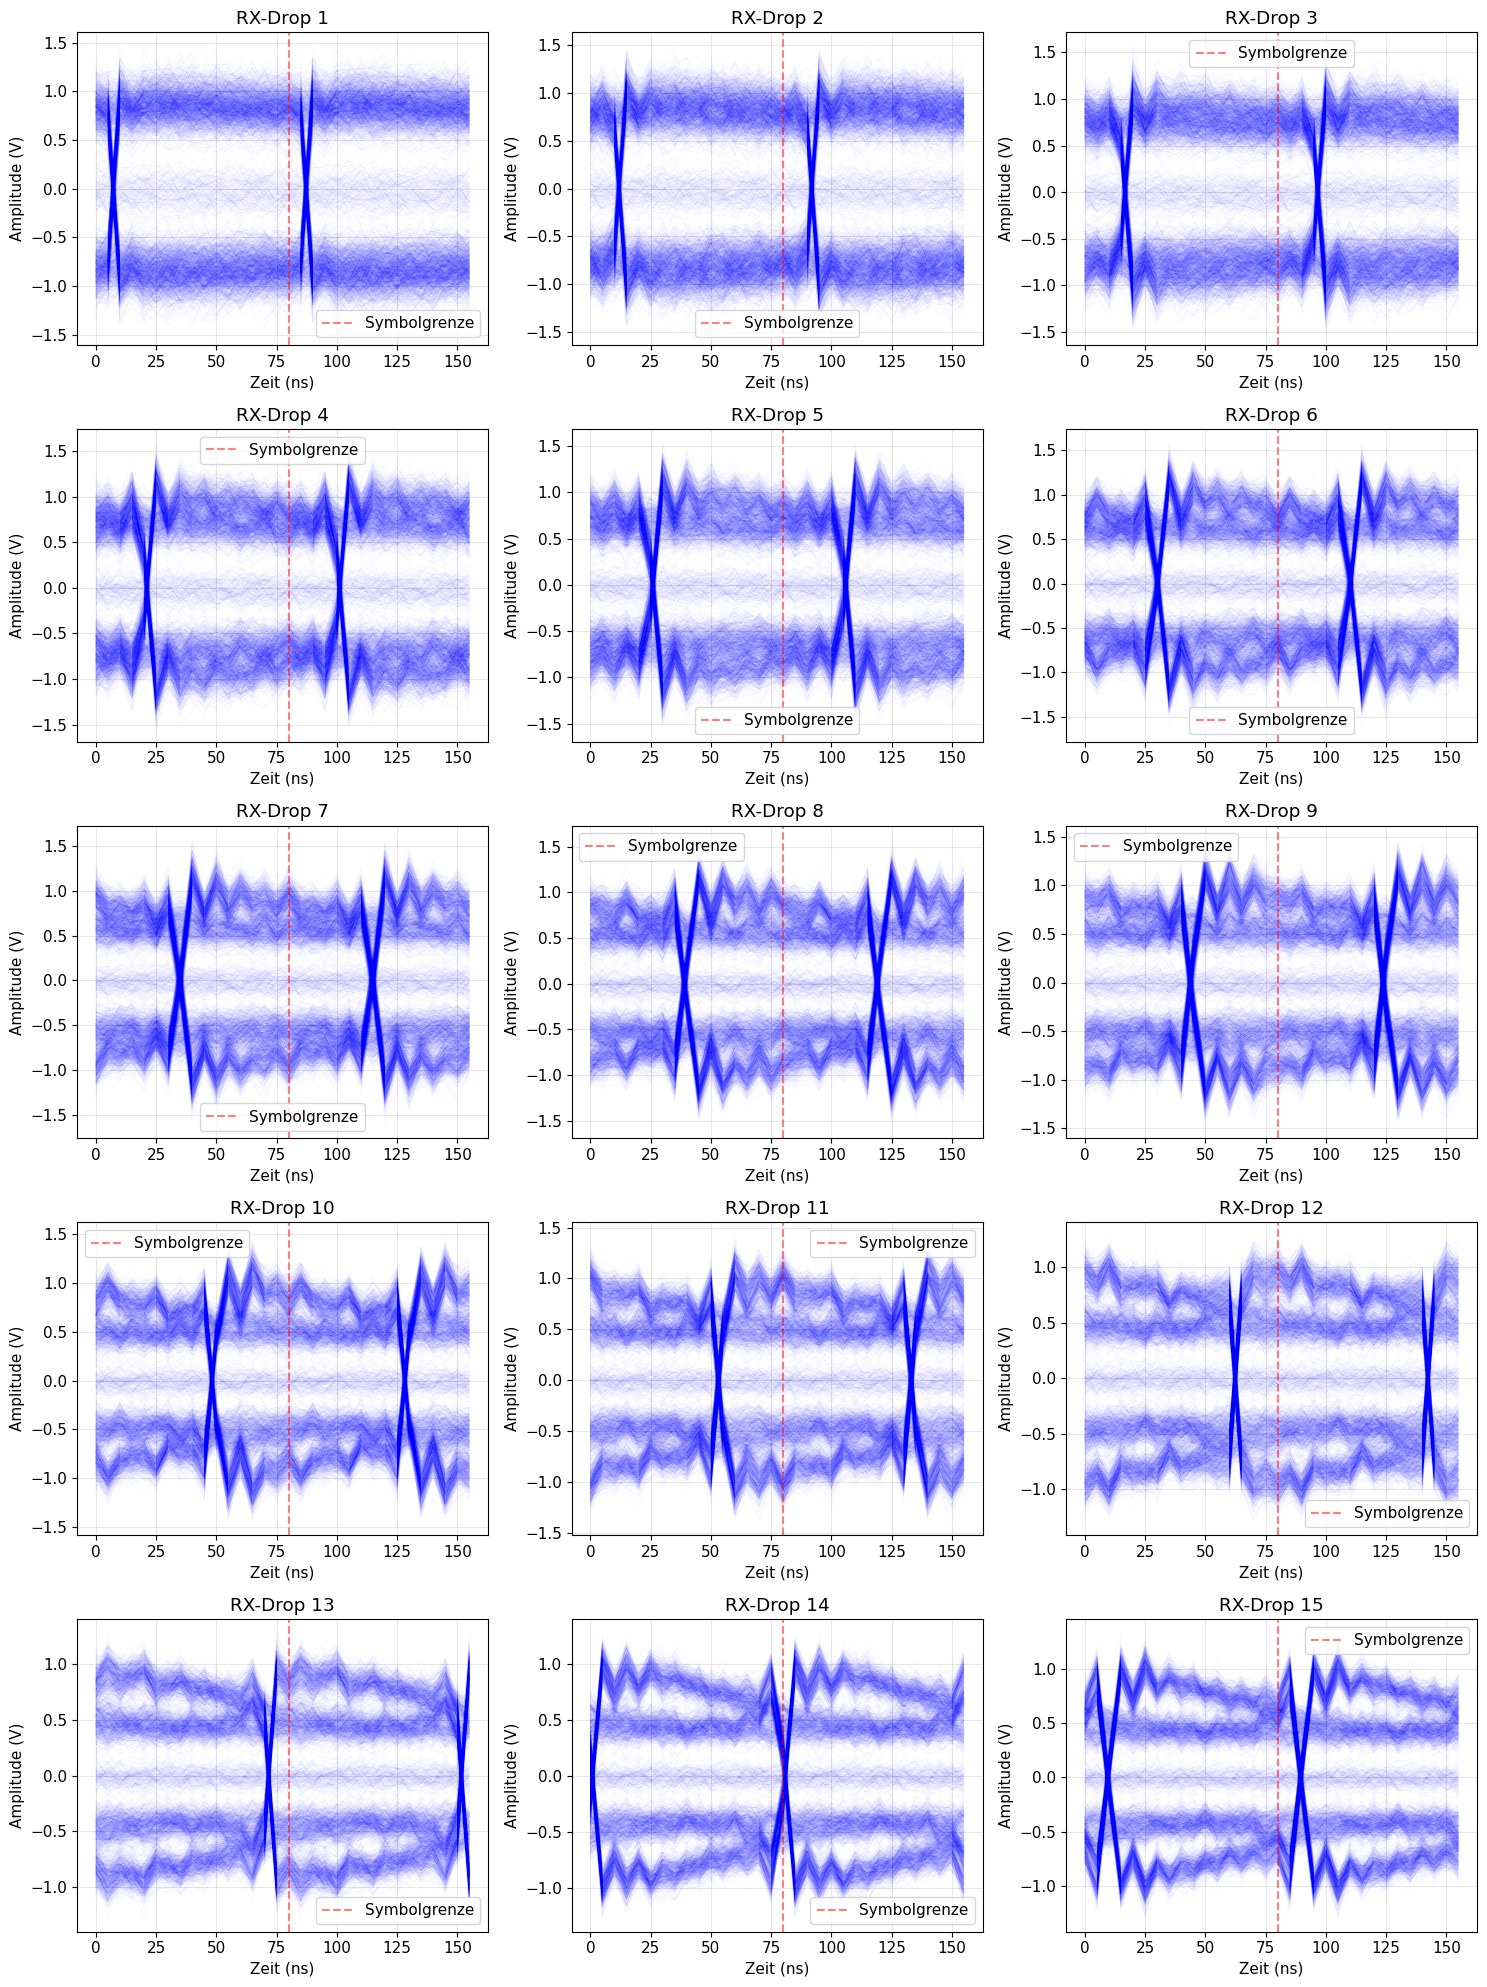

In [9]:
from spmd_reflection.postprocess.eye import compute_eye_diagram, plot_eye_diagram
import math

n_cols = 3
n_rows = math.ceil(n_rx / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for rx_idx in range(n_rx):
    eye = compute_eye_diagram(
        tx_voltage=tx_phy_voltage,
        rx_voltage=rx_phy_voltages[:, rx_idx],
        frequency_hz=results.frequency_hz)
    plot_eye_diagram(eye, ax=axes[rx_idx], title=f"RX-Drop {rx_idx+1}")

# Leere Subplots ausblenden
for i in range(n_rx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

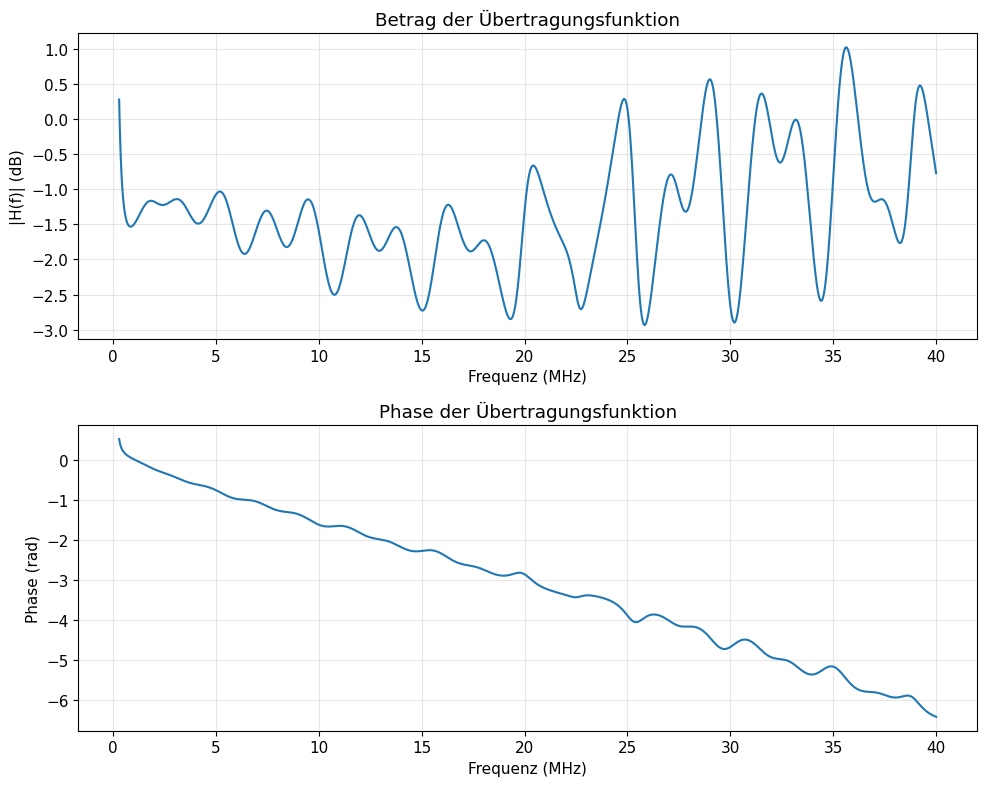

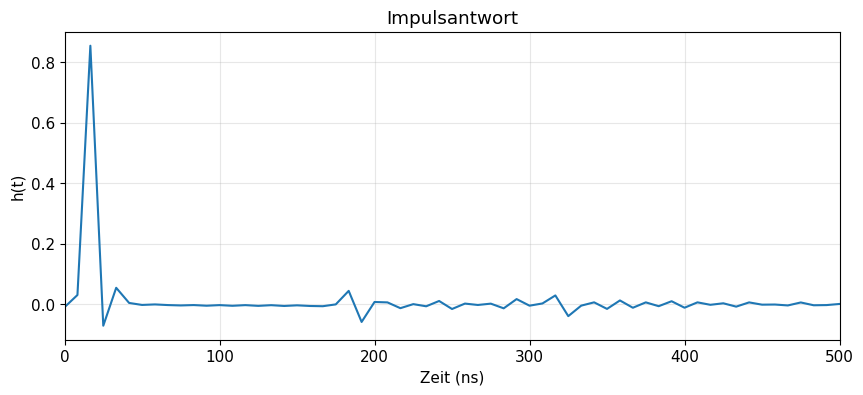

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Übertragungsfunktion anschauen
H = rx_phy_voltages[:, 0] / tx_phy_voltage

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(results.frequency_hz / 1e6, 20 * np.log10(np.abs(H)))
ax1.set_xlabel("Frequenz (MHz)")
ax1.set_ylabel("|H(f)| (dB)")
ax1.set_title("Betrag der Übertragungsfunktion")
ax1.grid(True)

ax2.plot(results.frequency_hz / 1e6, np.unwrap(np.angle(H)))
ax2.set_xlabel("Frequenz (MHz)")
ax2.set_ylabel("Phase (rad)")
ax2.set_title("Phase der Übertragungsfunktion")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Impulsantwort anschauen
from spmd_reflection.postprocess.eye import _compute_transfer_function, _transfer_function_to_impulse_response

h_freq = _compute_transfer_function(tx_phy_voltage, rx_phy_voltages[:, 0])
fs = 16 * 7.5e6
h_t = _transfer_function_to_impulse_response(h_freq, len(results.frequency_hz), fs)

fig2, ax3 = plt.subplots(figsize=(10, 4))
t = np.arange(len(h_t)) / fs * 1e9
ax3.plot(t, h_t)
ax3.set_xlabel("Zeit (ns)")
ax3.set_ylabel("h(t)")
ax3.set_title("Impulsantwort")
ax3.set_xlim([0, 500])
ax3.grid(True)
plt.show()